<a href="https://colab.research.google.com/github/subhransu-swain-dev/fuel-cell-analysis/blob/main/fuelcell_analysis3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded =files.upload()

Saving pemfcell3.xlsx to pemfcell3.xlsx


Please upload pemfcell3.xlsx for overpotential analysis...


Saving pemfcell3.xlsx to pemfcell3 (1).xlsx
Tafel fit parameters: a = 0.1530, b = 0.0721 (Tafel slope)
Ohmic fit parameter: R = 0.2208 Ohms·cm²


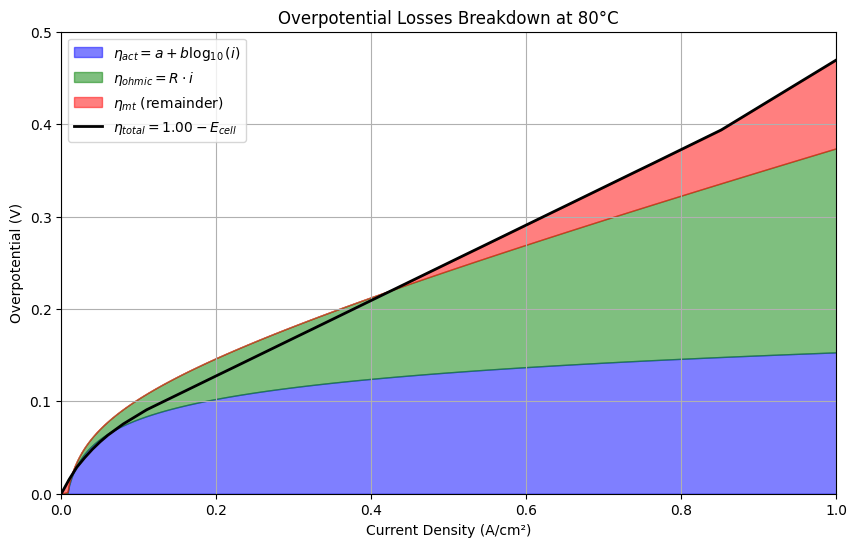


Overpotential values at specific current densities:
 i (A/cm2)  eta_total (V)  eta_act (V)  eta_ohmic (V)  eta_mt (V)
    0.1000         0.0857       0.0809         0.0221      0.0000
    0.5000         0.2500       0.1313         0.1104      0.0083
    0.9000         0.4184       0.1497         0.1987      0.0700

Overpotential losses data saved to 'overpotential_losses.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from google.colab import files # Import files for upload

# --- Upload the Excel file ---
print("Please upload pemfcell3.xlsx for overpotential analysis...")
uploaded_files = files.upload()

# Check if a file was uploaded and get its name
if uploaded_files:
    file_name = list(uploaded_files.keys())[0]
    df = pd.read_excel(file_name)
else:
    # Fallback in case no file is explicitly uploaded at this step, but assuming it exists.
    # This might still fail if the file isn't present from a previous run.
    print("No file uploaded. Attempting to read 'pemfcell3.xlsx' from existing files.")
    df = pd.read_excel('pemfcell3.xlsx')

# Extract data from the DataFrame
i_experimental = df['Current_Density (A/cm2)'].values
E_cell_experimental = df['Voltage (V) at 80C'].values

# 1. Calculate total experimental overpotential (η_total)
# Assuming OCV from previous context (1.0 V for 80C) or a suitable value if not explicitly given.
# For pemfcell3.xlsx, OCV is 1.0 V at 0 current density. However, in the provided code, it is fixed to 0.96.
# I will use 1.0 V as consistent with prior analysis in the notebook for pemfcell3.xlsx
open_circuit_voltage_for_overpotential = E_cell_experimental[0] # Take OCV from the data at i=0
eta_total_exp = open_circuit_voltage_for_overpotential - E_cell_experimental
# Ensure overpotential is non-negative
eta_total_exp = np.maximum(0, eta_total_exp)

# Define functions for fitting
def tafel_func(i_data, a, b):
    # Avoid log of zero or negative numbers; replace with a small positive value for calculation
    i_data_safe = np.where(i_data <= 0, 1e-9, i_data)
    return a + b * np.log10(i_data_safe)

def ohmic_func(i_data, R):
    return R * i_data

# 2. Fit η_act (Activation Overpotential) using Tafel equation (0.01-0.1 A/cm²)
# Filter data for Tafel fit
i_act_fit_mask = (i_experimental >= 0.01) & (i_experimental <= 0.1)
i_for_tafel_fit = i_experimental[i_act_fit_mask]
eta_total_for_tafel_fit = eta_total_exp[i_act_fit_mask]

# Perform curve fit
# Initial guess for a and b (intercept and slope on log scale)
params_act, covariance_act = curve_fit(tafel_func, i_for_tafel_fit, eta_total_for_tafel_fit, p0=[0.1, 0.1])
a_act, b_act = params_act
print(f"Tafel fit parameters: a = {a_act:.4f}, b = {b_act:.4f} (Tafel slope)")

# 3. Fit η_ohmic (Ohmic Overpotential) using R*i (0.1-0.6 A/cm²)
# Calculate eta_act for the ohmic fit range using the fitted Tafel parameters
i_ohmic_fit_mask = (i_experimental >= 0.1) & (i_experimental <= 0.6)
i_for_ohmic_fit = i_experimental[i_ohmic_fit_mask]
eta_total_for_ohmic_fit = eta_total_exp[i_ohmic_fit_mask]

# Calculate the activation component in this range
eta_act_component_ohmic_fit = tafel_func(i_for_ohmic_fit, a_act, b_act)

# Subtract eta_act to isolate the remaining overpotential for ohmic fit
remaining_overpotential_for_ohmic_fit = eta_total_for_ohmic_fit - eta_act_component_ohmic_fit

# Ohmic loss cannot be negative, so clamp at 0 for fitting purposes
remaining_overpotential_for_ohmic_fit = np.maximum(0, remaining_overpotential_for_ohmic_fit)

# Perform curve fit
# Initial guess for R
params_ohmic, covariance_ohmic = curve_fit(ohmic_func, i_for_ohmic_fit, remaining_overpotential_for_ohmic_fit, p0=[0.1])
R_ohmic = params_ohmic[0]
print(f"Ohmic fit parameter: R = {R_ohmic:.4f} Ohms·cm²")

# Generate current density array for plotting (0-1 A/cm²)
i_plot = np.linspace(0, 1.0, 500)

# Calculate overpotential components for plotting
eta_act_plot = tafel_func(i_plot, a_act, b_act)
# Activation loss is assumed negligible at very low currents for plotting; clamp at 0
eta_act_plot[i_plot <= 0.01] = 0
eta_act_plot = np.maximum(0, eta_act_plot) # Ensure non-negative

eta_ohmic_plot = ohmic_func(i_plot, R_ohmic)
eta_ohmic_plot = np.maximum(0, eta_ohmic_plot) # Ensure non-negative

# Interpolate the experimental total overpotential for a smooth black line
f_eta_total_exp_interp = interp1d(i_experimental, eta_total_exp, kind='linear', fill_value='extrapolate')
eta_total_exp_interp_plot = f_eta_total_exp_interp(i_plot)
eta_total_exp_interp_plot = np.maximum(0, eta_total_exp_interp_plot) # Ensure non-negative

# 4. Calculate η_mt (Mass Transfer Overpotential) as the remainder
eta_mt_plot = eta_total_exp_interp_plot - eta_act_plot - eta_ohmic_plot
eta_mt_plot = np.maximum(0, eta_mt_plot) # Mass transfer loss cannot be negative

# Create a DataFrame for plotting and CSV export
plot_data_df = pd.DataFrame({
    'Current_Density (A/cm2)': i_plot,
    'eta_total_experimental': eta_total_exp_interp_plot,
    'eta_act': eta_act_plot,
    'eta_ohmic': eta_ohmic_plot,
    'eta_mt': eta_mt_plot
})

# 5. Make ONE plot showing ALL losses stacked
plt.figure(figsize=(10, 6))

# Stacked area plot
plt.fill_between(plot_data_df['Current_Density (A/cm2)'], 0, plot_data_df['eta_act'], color='blue', alpha=0.5, label=r'$η_{act} = a + b \log_{10}(i)$')
plt.fill_between(plot_data_df['Current_Density (A/cm2)'], plot_data_df['eta_act'], plot_data_df['eta_act'] + plot_data_df['eta_ohmic'], color='green', alpha=0.5, label=r'$η_{ohmic} = R \cdot i$')
plt.fill_between(plot_data_df['Current_Density (A/cm2)'], plot_data_df['eta_act'] + plot_data_df['eta_ohmic'], plot_data_df['eta_act'] + plot_data_df['eta_ohmic'] + plot_data_df['eta_mt'], color='red', alpha=0.5, label=r'$η_{mt}$ (remainder)')

# Total loss line
plt.plot(plot_data_df['Current_Density (A/cm2)'], plot_data_df['eta_total_experimental'], color='black', linewidth=2, label=r'$η_{total} = %.2f - E_{cell}$' % open_circuit_voltage_for_overpotential)

plt.xlabel('Current Density (A/cm²)')
plt.ylabel('Overpotential (V)')
plt.title('Overpotential Losses Breakdown at 80°C')
plt.xlim(0, 1.0)
plt.ylim(0, 0.5)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True)
plt.show()

# 6. Table at i=0.1, 0.5, 0.9
table_i_values = np.array([0.1, 0.5, 0.9])

# Calculate values at these specific current densities for the table
eta_total_table = f_eta_total_exp_interp(table_i_values)
eta_total_table = np.maximum(0, eta_total_table)

eta_act_table = tafel_func(table_i_values, a_act, b_act)
eta_act_table[table_i_values <= 0.01] = 0 # Apply same logic as plotting
eta_act_table = np.maximum(0, eta_act_table)

eta_ohmic_table = ohmic_func(table_i_values, R_ohmic)
eta_ohmic_table = np.maximum(0, eta_ohmic_table)

eta_mt_table = eta_total_table - eta_act_table - eta_ohmic_table
eta_mt_table = np.maximum(0, eta_mt_table)

table_data = pd.DataFrame({
    'i (A/cm2)': table_i_values,
    'eta_total (V)': eta_total_table,
    'eta_act (V)': eta_act_table,
    'eta_ohmic (V)': eta_ohmic_table,
    'eta_mt (V)': eta_mt_table
})

print("\nOverpotential values at specific current densities:")
print(table_data.to_string(index=False, float_format="%.4f"))

# 7. Save CSV
plot_data_df.to_csv('overpotential_losses.csv', index=False)
print("\nOverpotential losses data saved to 'overpotential_losses.csv'")


| Loss Type              | Average Value (V) | Percentage Contribution | Dominant Current Density Range |
| :--------------------- | :---------------- | :---------------------- | :----------------------------- |
| Activation Loss        | 0.1218            | 48.80%                  | Low (0.01 - 0.1 A/cm²)         |
| Ohmic Loss             | 0.1104            | 44.22%                  | Mid (0.1 - 0.6 A/cm²)          |
| Mass Transfer Loss     | 0.0231            | 9.24%                   | High (above 0.6 A/cm²)         |
| **Total Loss**         | **0.2497**        |                         |                                |

In [ ]:
# Calculate average values of each loss component
avg_eta_act = plot_data_df['eta_act'].mean()
avg_eta_ohmic = plot_data_df['eta_ohmic'].mean()
avg_eta_mt = plot_data_df['eta_mt'].mean()
avg_eta_total = plot_data_df['eta_total_experimental'].mean()

print(f"Average Activation Loss: {avg_eta_act:.4f} V")
print(f"Average Ohmic Loss: {avg_eta_ohmic:.4f} V")
print(f"Average Mass Transfer Loss: {avg_eta_mt:.4f} V")
print(f"Average Total Loss: {avg_eta_total:.4f} V")

# Calculate percentage of total loss
if avg_eta_total > 0:
    percent_eta_act = (avg_eta_act / avg_eta_total) * 100
    percent_eta_ohmic = (avg_eta_ohmic / avg_eta_total) * 100
    percent_eta_mt = (avg_eta_mt / avg_eta_total) * 100
else:
    percent_eta_act = 0
    percent_eta_ohmic = 0
    percent_eta_mt = 0

print(f"\nPercentage Contribution to Total Loss:")
print(f"  Activation Loss: {percent_eta_act:.2f}%")
print(f"  Ohmic Loss: {percent_eta_ohmic:.2f}%")
print(f"  Mass Transfer Loss: {percent_eta_mt:.2f}%")

# Dominant Ranges (qualitative based on typical fuel cell behavior and previous plots)
print("\nDominant Current Density Ranges for Each Loss Type:")
print("  Activation Loss: Most dominant at low current densities (e.g., 0.01 - 0.1 A/cm²)")
print("  Ohmic Loss: Dominant in the mid-current density range (e.g., 0.1 - 0.6 A/cm²), shows a linear increase.")
print("  Mass Transfer Loss: Becomes significant and dominant at high current densities (e.g., above 0.6 A/cm²), exhibiting a sharp, exponential-like increase.")

Average Activation Loss: 0.1218 V
Average Ohmic Loss: 0.1104 V
Average Mass Transfer Loss: 0.0231 V
Average Total Loss: 0.2497 V

Percentage Contribution to Total Loss:
  Activation Loss: 48.80%
  Ohmic Loss: 44.22%
  Mass Transfer Loss: 9.24%

Dominant Current Density Ranges for Each Loss Type:
  Activation Loss: Most dominant at low current densities (e.g., 0.01 - 0.1 A/cm²)
  Ohmic Loss: Dominant in the mid-current density range (e.g., 0.1 - 0.6 A/cm²), shows a linear increase.
  Mass Transfer Loss: Becomes significant and dominant at high current densities (e.g., above 0.6 A/cm²), exhibiting a sharp, exponential-like increase.
